<a href="https://colab.research.google.com/github/srihari-g-acharya-ci109/ML2LAB/blob/main/ML4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Dataset shape: (20000, 785)

First 5 rows of the original dataset (labels and pixels):


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Using simplified features: ['pixel_100', 'pixel_150', 'pixel_200', 'pixel_250', 'pixel_300', 'pixel_350']
Target column 'Target_Digit' (original label) and 'Class' (binary label):
    Target_Digit     Class  pixel_100  pixel_150  pixel_200  pixel_250  \
0              6  Negative          0          0          0          0   
1              5  Negative          0          0          0          0   
2              7  Negative          0          0          0          0   
3              9  Negative          0          0          0          0   
4              5  Negative          0          0          0          0   
5              2  Negative          0          0          0          0   
6              0  Positive          0          1          0          0   
7              6  Negative          1          0          0          0   
8              5  Negative          0          0          0          0   
9              5  Negative          0          0          0          0   
10   

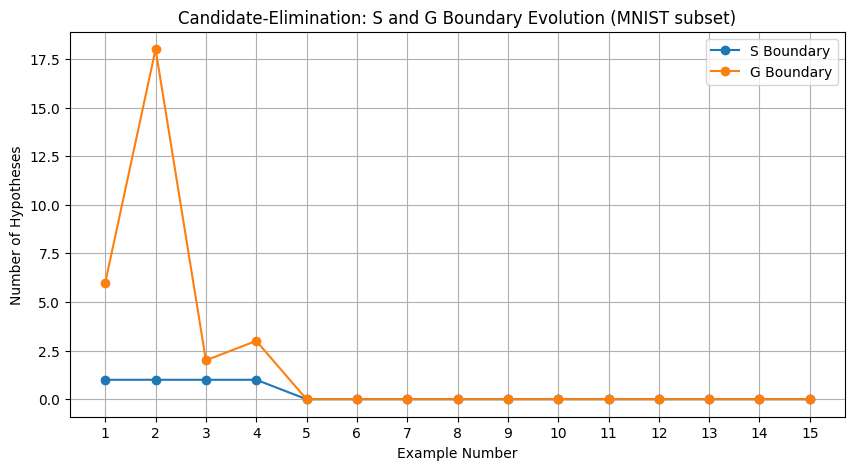

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

original_df = pd.read_csv("/content/sample_data/mnist_train_small.csv", header=None)

print("Original Dataset shape:", original_df.shape)
print("\nFirst 5 rows of the original dataset (labels and pixels):")
display(original_df.head())

original_df['Target_Digit'] = original_df[0]

original_df["Class"] = original_df["Target_Digit"].apply(
    lambda x: "Positive" if x == 0 else "Negative"
)

pixel_feature_indices = [100, 150, 200, 250, 300, 350]
features = ['pixel_' + str(i) for i in pixel_feature_indices]

for i, original_col_index in enumerate(pixel_feature_indices):
    original_df[features[i]] = original_df[original_col_index].apply(lambda x: 1 if x > 0 else 0)

print(f"\nUsing simplified features: {features}")
print("Target column 'Target_Digit' (original label) and 'Class' (binary label):")
print(original_df[['Target_Digit', 'Class'] + features].head(15))
print("\nClass distribution:")
print(original_df["Class"].value_counts())

num_positive_samples = 8
num_negative_samples = 7

positive_samples = original_df[original_df["Class"] == "Positive"].sample(n=num_positive_samples, random_state=42)
negative_samples = original_df[original_df["Class"] == "Negative"].sample(n=num_negative_samples, random_state=42)

sample_df = pd.concat([positive_samples, negative_samples]).reset_index(drop=True)

sample_df = sample_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nSelected 15 examples for Candidate-Elimination:")
print(sample_df[['Target_Digit', 'Class'] + features])

def covers(hypothesis, example):
    for h, x in zip(hypothesis, example):
        if h == "Ø":
            return False
        if h != "?" and h != x:
            return False
    return True

def more_general_or_equal(h1, h2):
    for a, b in zip(h1, h2):
        if b == "Ø":
            continue
        if a == "Ø":
            return False
        if b != "?" and a == "?":
            continue
        if a != "?" and a != b:
            return False
    return True

def minimal_specializations(hypothesis, example, domains):
    specializations = set()
    for i in range(len(hypothesis)):
        if hypothesis[i] == "?":
            for value in domains[features[i]]:
                if value != example[i]:
                    new_h = list(hypothesis)
                    new_h[i] = value
                    specializations.add(tuple(new_h))
    return specializations

domains = {
    feature: [0, 1] for feature in features
}

S = {
    tuple(["Ø"] * len(features))
}

G = {
    tuple(["?"] * len(features))
}

S_history = []
G_history = []

for _, row in sample_df.iterrows():
    example = tuple(row[feature] for feature in features)

    if row["Class"] == "Positive":
        G = {g for g in G if covers(g, example)}

        new_S = set()
        for s in S:
            if covers(s, example):
                new_S.add(s)
            else:
                h = list(s)
                for i in range(len(features)):
                    if s[i] == "Ø":
                        h[i] = example[i]
                    elif s[i] != example[i]:
                        h[i] = "?"
                h = tuple(h)

                if any(more_general_or_equal(g, h) for g in G):
                    new_S.add(h)
        S = new_S

    else:
        new_G = set()
        for g in G:
            if not covers(g, example):
                new_G.add(g)
            else:
                specializations = set()
                for i in range(len(features)):
                    if g[i] == "?":
                        for value in domains[features[i]]:
                            if value != example[i]:
                                h_spec = list(g)
                                h_spec[i] = value
                                h_spec = tuple(h_spec)
                                if any(more_general_or_equal(h_spec, s) for s in S):
                                    specializations.add(h_spec)
                new_G.update(specializations)
        G = new_G

    S_history.append(S.copy())
    G_history.append(G.copy())

for i in range(len(sample_df)):
    print("\n" + "=" * 60)
    print(f"AFTER EXAMPLE {i + 1} (Original Target: {sample_df.iloc[i]['Target_Digit']})")
    print("=" * 60)
    print("Class :", sample_df.iloc[i]["Class"])
    print("Features:", tuple(sample_df.iloc[i][feature] for feature in features))

    print("\nS Boundary:")
    for s in S_history[i]:
        print(s)

    print("\nG Boundary:")
    for g in G_history[i]:
        print(g)

S_count = [len(s) for s in S_history]
G_count = [len(g) for g in G_history]
examples = range(1, len(sample_df) + 1)

plt.figure(figsize=(10, 5))
plt.plot(examples, S_count, marker="o", label="S Boundary")
plt.plot(examples, G_count, marker="o", label="G Boundary")
plt.xlabel("Example Number")
plt.ylabel("Number of Hypotheses")
plt.title("Candidate-Elimination: S and G Boundary Evolution (MNIST subset)")
plt.xticks(range(1, len(sample_df) + 1))
plt.legend()
plt.grid(True)
plt.show()